 LINEAR REGRESSION MODEL TO TRACK STUDENT PERFORMANCE

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder # for scaling and encoding
from sklearn.model_selection import train_test_split

performance = pd.read_csv('Student_Performance.csv')
performance

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [3]:
performance.head(10)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
5,3,78,No,9,6,61.0
6,7,73,Yes,5,6,63.0
7,8,45,Yes,4,6,42.0
8,5,77,No,8,2,61.0
9,4,89,No,4,0,69.0


In [4]:
#SETTING A NAME FO THE INDEX

performance.index.name='Student_No'
performance


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
Student_No,,,,,,
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0


In [5]:
print(performance.isnull().sum(),'\n')         # count missing per column
print(df.isnull().mean() * 100)                # % missing per column

# IF MORE THAT 50% OF THE VALUES ARE MISSING YOU CAN CHOOSE TO DROP THE COLUMN BUT IF IT IS NUMERICAL YOU CAN FILL IT USING A SPECIFIC VALUE

# CHECKING THE NUMBER OF DUPLICATES IN THE DATASET
print("THE NUMBER OF DUPLICATE RECORDS IS: ", performance.duplicated().sum())


Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64 



NameError: name 'df' is not defined

In [ ]:

# REMOVE THE DUPLICATE RECORDS

performance = performance.drop_duplicates()
performance

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
Student_No,,,,,,
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0


In [ ]:
performance.info()
print("\n")
performance.describe()

<class 'pandas.DataFrame'>
Index: 9873 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     9873 non-null   int64  
 1   Previous Scores                   9873 non-null   int64  
 2   Extracurricular Activities        9873 non-null   str    
 3   Sleep Hours                       9873 non-null   int64  
 4   Sample Question Papers Practiced  9873 non-null   int64  
 5   Performance Index                 9873 non-null   float64
dtypes: float64(1), int64(4), str(1)
memory usage: 539.9 KB




,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,9873.000000,9873.000000,9873.000000,9873.000000,9873.000000
mean,4.992100,69.441102,6.531652,4.583004,55.216651
std,2.589081,17.325601,1.697683,2.867202,19.208570
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,70.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


ANALYTICAL GRAPHS FOR EACH FEATURE

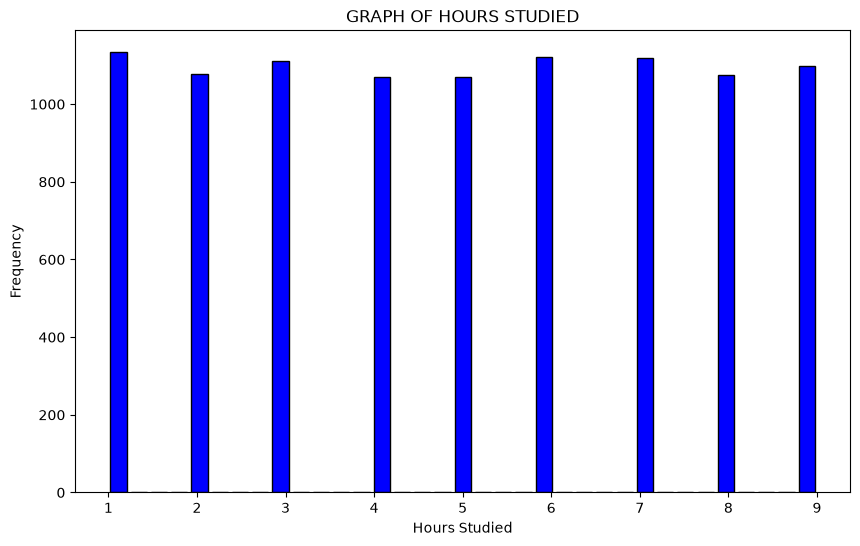

In [ ]:
fig =px.histogram(
    performance,
    x='Hours Studied',
    marginal='box',
    color_discrete_sequence= ['blue'],
    nbins = 25,
    title = 'GRAPH OF HOURS STUDIED'
)

fig.update_layout(bargap=0)
fig.show()

# USING PYPLOT
plt.figure(figsize=(10, 6))
plt.hist(
    performance['Hours Studied'],
    bins=35,
    color='blue',
    edgecolor='black',
    rwidth=0.8
)

plt.title('GRAPH OF HOURS STUDIED')
plt.xlabel('Hours Studied')
plt.ylabel('Frequency')

plt.show()


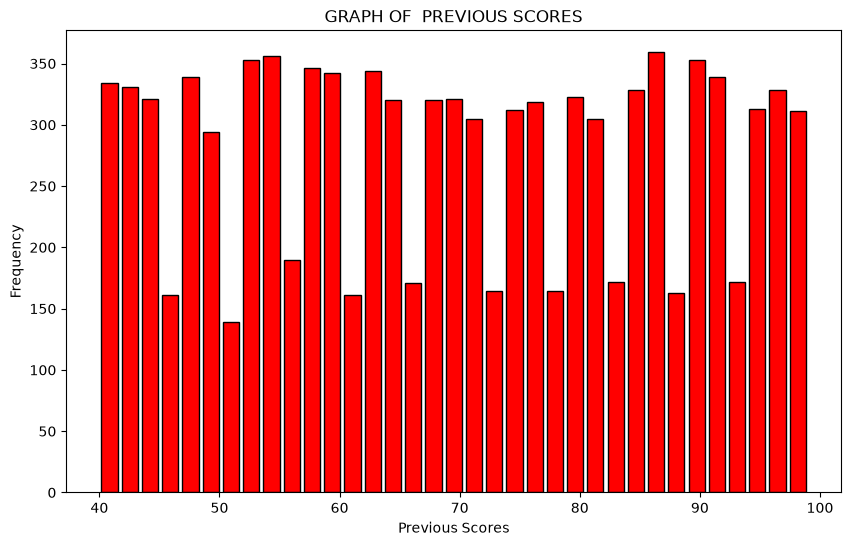

In [ ]:
fig =px.histogram(
    performance,
    x='Previous Scores',
    marginal='box',
    color_discrete_sequence= ['red'],
    nbins = 35,
    title = 'GRAPH OF PREVIOUS SCORES'
)

fig.update_layout(bargap=0.1)
fig.show()

# USING PYPLOT
plt.figure(figsize=(10, 6))
plt.hist(
    performance['Previous Scores'],
    bins=35,
    color='red',
    edgecolor='black',
    rwidth=0.8
)

plt.title('GRAPH OF  PREVIOUS SCORES')
plt.xlabel('Previous Scores')
plt.ylabel('Frequency')

plt.show()


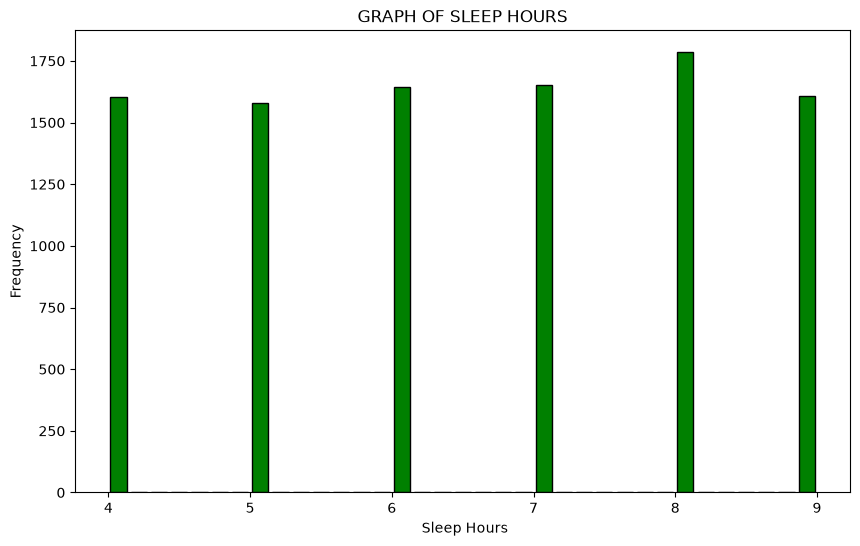

In [ ]:
fig =px.histogram(
    performance,
    x='Sleep Hours',
    marginal='box',
    color_discrete_sequence= ['green'],
    nbins = 25,
    title = 'GRAPH OF SLEEP HOURS'
)

fig.update_layout(bargap=0)
fig.show()

# USING PYPLOT
plt.figure(figsize=(10, 6))
plt.hist(
    performance['Sleep Hours'],
    bins=35,
    color='green',
    edgecolor='black',
    rwidth=0.8
)

plt.title('GRAPH OF SLEEP HOURS')
plt.xlabel(' Sleep Hours')
plt.ylabel('Frequency')

plt.show()


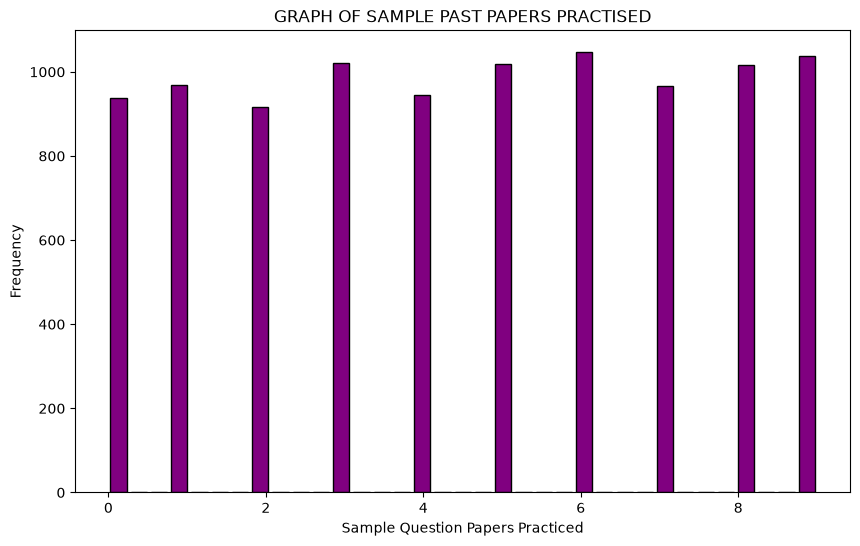

In [ ]:
fig =px.histogram(
    performance,
    x='Sample Question Papers Practiced',
    marginal='box',
    color_discrete_sequence= ['purple'],
    nbins = 35,
    title = 'GRAPH OF SAMPLE PAST PAPERS PRACTISED'
)

fig.update_layout(bargap=0)
fig.show()


# USING PYPLOT
plt.figure(figsize=(10, 6))
plt.hist(
    performance['Sample Question Papers Practiced'],
    bins=35,
    color='purple',
    edgecolor='black',
    rwidth=0.8
)

plt.title('GRAPH OF SAMPLE PAST PAPERS PRACTISED')
plt.xlabel('Sample Question Papers Practiced')
plt.ylabel('Frequency')

plt.show()




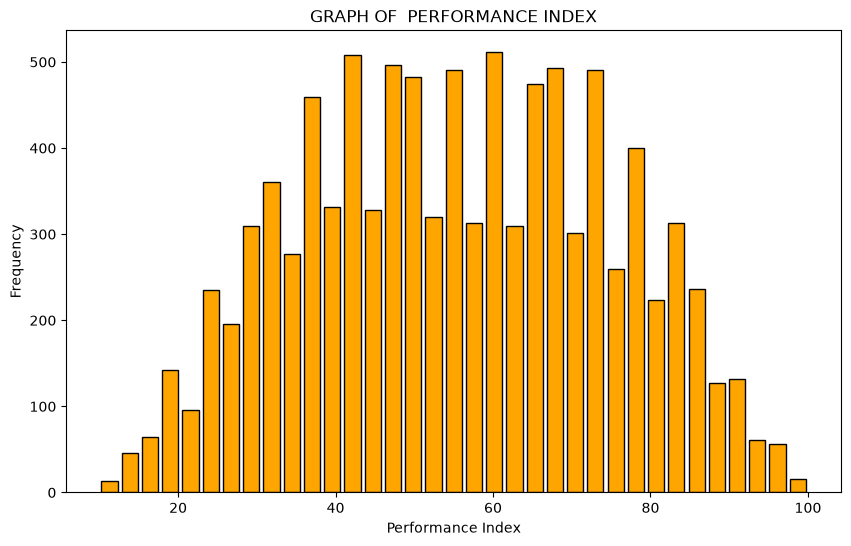

In [ ]:
fig =px.histogram(
    performance,
    x='Performance Index',
    marginal='box',
    color_discrete_sequence= ['orange'],
    nbins = 35,
    title = 'GRAPH OF SAMPLE PAST PAPERS PRACTISED'
)

fig.update_layout(bargap=0.2)
fig.show()

print("\n")

# USING PYPLOT  
plt.figure(figsize=(10, 6))
plt.hist(
    performance['Performance Index'],
    bins=35,
    color='orange',
    edgecolor='black',
    rwidth=0.8
)

plt.title('GRAPH OF  PERFORMANCE INDEX')
plt.xlabel('Performance Index')
plt.ylabel('Frequency')

plt.show()




1.IDENTIFICATION OF TARGET FEATURE -> Performance Index

2.CHECKING CORRELATION BETWEEN FEATURES

In [ ]:
performance.info()

<class 'pandas.DataFrame'>
Index: 9873 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     9873 non-null   int64  
 1   Previous Scores                   9873 non-null   int64  
 2   Extracurricular Activities        9873 non-null   str    
 3   Sleep Hours                       9873 non-null   int64  
 4   Sample Question Papers Practiced  9873 non-null   int64  
 5   Performance Index                 9873 non-null   float64
dtypes: float64(1), int64(4), str(1)
memory usage: 539.9 KB


In [ ]:
print("THE CORRELATION BETWEEN PERFORMANCE INDEX AND HOURS STUDIED IS: ",performance['Performance Index'].corr(performance['Hours Studied']))

print("THE CORRELATION BETWEEN PERFORMANCE INDEX AND PREVIOUS SCORES IS: ",performance['Performance Index'].corr(performance['Previous Scores']))

extracurricular_values = {'Yes': 1, 'No': 0}
extracurricular_numeric = performance['Extracurricular Activities'].map(extracurricular_values)
print("THE CORRELATION BETWEEN PERFORMANCE INDEX AND EXTRACURRICULAR ACTIVITIES IS: ",performance['Performance Index'].corr(extracurricular_numeric))

print("THE CORRELATION BETWEEN PERFORMANCE INDEX AND SLEEP HOURS IS: ",performance['Performance Index'].corr(performance['Sleep Hours']))

print("THE CORRELATION BETWEEN PERFORMANCE INDEX AND SAMPLE QUESTION PAPERS PRACTICED IS: ",performance['Performance Index'].corr(performance['Sample Question Papers Practiced']))

THE CORRELATION BETWEEN PERFORMANCE INDEX AND HOURS STUDIED IS:  0.3753320270787472
THE CORRELATION BETWEEN PERFORMANCE INDEX AND PREVIOUS SCORES IS:  0.9151350792024562
THE CORRELATION BETWEEN PERFORMANCE INDEX AND EXTRACURRICULAR ACTIVITIES IS:  0.026074591573450736
THE CORRELATION BETWEEN PERFORMANCE INDEX AND SLEEP HOURS IS:  0.0503524739178474
THE CORRELATION BETWEEN PERFORMANCE INDEX AND SAMPLE QUESTION PAPERS PRACTICED IS:  0.0434357135254208


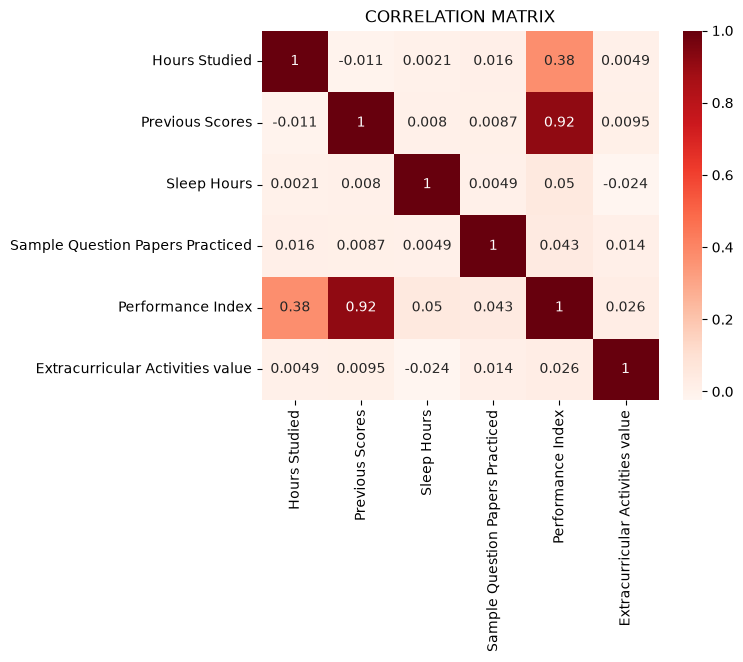

In [ ]:
# Map Yes/No to 1/0 so it's included in the correlation matrix
performance['Extracurricular Activities value'] = performance['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

matrix = performance.drop(columns=['Extracurricular Activities']).corr()

sns.heatmap(matrix, cmap='Reds', annot=True)
plt.title("CORRELATION MATRIX")
plt.show()

In [ ]:
performance.info()

<class 'pandas.DataFrame'>
Index: 9873 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     9873 non-null   int64  
 1   Previous Scores                   9873 non-null   int64  
 2   Extracurricular Activities        9873 non-null   str    
 3   Sleep Hours                       9873 non-null   int64  
 4   Sample Question Papers Practiced  9873 non-null   int64  
 5   Performance Index                 9873 non-null   float64
 6   Extracurricular Activities value  9873 non-null   int64  
dtypes: float64(1), int64(5), str(1)
memory usage: 617.1 KB


PLOTTING THE RELATIONSHIP BETWEEN THE PERFORMANCE INDEX AND THE INPUT FEATURES

Y = a1X1 + a2X2 +.......+anXn + b
where:
   a = slope
   X = corresponding feature
   b = Intercept

Performance Index = (a1 x Previous Scores) +(a2 x Hours Studied)+ (a3 x Sleep Hours)+ (a4 x Sample Question Papers Practiced)+ (a5 x Extracurricular Activities value)+ b

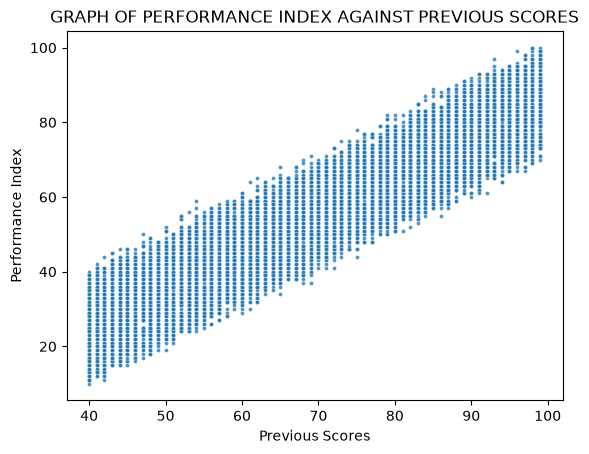

In [ ]:
# VISUALIZING THE RELATIONSHIP BETWEEN PREVIOUS SCORES AND THE PERFORMANCE INDEX

fig =px.scatter(
    performance,
    x='Previous Scores',
    y='Performance Index',
    opacity=0.8,
    title=' GRAPH OF  PERFORMANCE INDEX AGAINST PREVIOUS SCORES'
)

# fig.update_layout(bargap=0.5)
fig.show()


sns.scatterplot(x='Previous Scores', y='Performance Index', data=performance, s=8, alpha=0.8)
plt.xlabel('Previous Scores')
plt.ylabel('Performance Index')
plt.title('GRAPH OF PERFORMANCE INDEX AGAINST PREVIOUS SCORES')
plt.show()

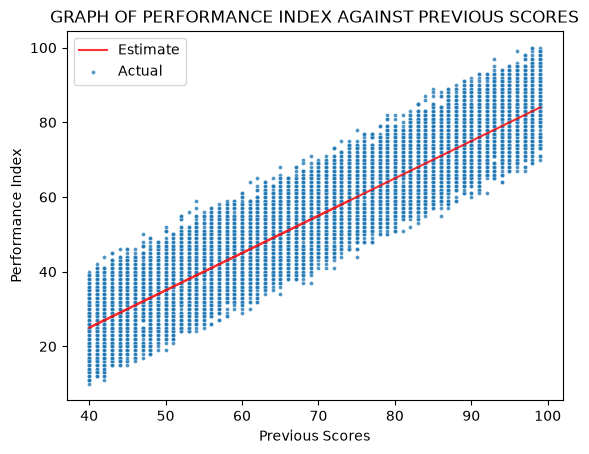

In [23]:

# FUNCTION TO GET ESTIMATED PERFORMANCE INDEX
def estimate_index(input,a,B):
     return a *input + B
a= 1
B= -15
input = performance['Previous Scores']
actual_target = performance['Performance Index']
estimated_target = estimate_index(input,a,B)

plt.plot(input, estimated_target, 'r', alpha=0.8)
sns.scatterplot(x=input,  y=actual_target, s=8, alpha=0.8)
plt.xlabel('Previous Scores')
plt.ylabel('Performance Index')
plt.title('GRAPH OF PERFORMANCE INDEX AGAINST PREVIOUS SCORES')
plt.legend(['Estimate', 'Actual'])
plt.show()

In [26]:
# FUNCTION TO GET ESTIMATED PERFORMANCE INDEX USING PLOTLY
def estimate_index(input, a, B):
    return a * input + B

a = 1.0138367
B = -15.181799427126165
input = performance['Previous Scores']
actual_target = performance['Performance Index']
estimated_target = estimate_index(input, a, B)

fig = go.Figure()

# Actual data points
fig.add_trace(go.Scatter(
    x=input, y=actual_target,
    mode='markers',
    marker=dict(size=8, opacity=0.8),
    name='Actual'
))

# Estimated line
fig.add_trace(go.Scatter(
    x=input, y=estimated_target,
    mode='lines',
    line=dict(color='red'),
    opacity=0.8,
    name='Estimated'
))

fig.update_layout(
    title='GRAPH OF PERFORMANCE INDEX AGAINST PREVIOUS SCORES',
    xaxis_title='Previous Scores',
    yaxis_title='Performance Index'
)

fig.show()

In [11]:
# MANUAL CONFIGURATION OF THE PERFORMANCE INDEXES
print("THESE ARE THE MODEL PREDICTED THE PERFORMANCE INDEX: \n\n",estimated_target)

print("THESE ARE THE ACTUAL FARE CHARGES: \n\n",actual_target)


THESE ARE THE MODEL PREDICTED THE PERFORMANCE INDEX: 

 Student_No
0       84
1       67
2       36
3       37
4       60
        ..
9995    34
9996    49
9997    68
9998    82
9999    59
Name: Previous Scores, Length: 10000, dtype: int64
THESE ARE THE ACTUAL FARE CHARGES: 

 Student_No
0       91.0
1       65.0
2       45.0
3       36.0
4       66.0
        ... 
9995    23.0
9996    58.0
9997    74.0
9998    95.0
9999    64.0
Name: Performance Index, Length: 10000, dtype: float64


                       LINEAR REGRESSION USING A SINGLE FEATURE (PREVIOUS SCORES)

LOSS / COST FUNCTION -> TO MEASURE NUMERICALLY HOW WELL THE LINE FITS THE POINTS

 This is done by comparing the model's predictions with the actual targets to get a single number -> root mean square error(RMSE)

 WHY WE NEED THIS:
 Visually inspecting the plot only gives a rough idea of fit.
 A cost function gives us an exact number so we can compare
 different values of W and B objectively, and later find the
 combination that minimizes this error (best fit line).

 RMSE FORMULA:
   RMSE = sqrt( (1/n) * sum( (actual_i - predicted_i)^2 ) )

 STEP-BY-STEP:
 1. error_i        = actual_i - predicted_i        (residual for each point)
 2. squared_error_i = error_i ** 2                  (penalize larger errors more, remove sign)
 3. mean_squared_error = mean(squared_error_i)      (average over all n points)
 4. RMSE = sqrt(mean_squared_error)                 (bring units back to original scale, e.g. Fare)

 LOWER RMSE -> BETTER FIT (predictions closer to actual values)
 HIGHER RMSE -> WORSE FIT (predictions far from actual values)




In [12]:
# DEMONSTRATION ON FINDING LOSS MANUALLY

def rmse (actual_target, estimated_target):
    return np.sqrt(np.mean(np.square(actual_target, estimated_target)))

a = 1
b = -15
estimated_target = estimate_index(input, a, b)
actual_target = performance['Previous Scores']

print("THE RMSE IS: ",rmse(actual_target, estimated_target))
print("COMPARE IT TO EITHER THE MEAN, MEDIAN, MIN AND MAX of the target")


THE RMSE IS:  71.57834938024207
COMPARE IT TO EITHER THE MEAN, MEDIAN, MIN AND MAX of the target


In [25]:
inputs = performance[['Previous Scores']]
targets = performance['Performance Index']


one_feature_model= LinearRegression()
one_feature_model.fit(inputs, targets)
one_feature_predictions= one_feature_model.predict(inputs)

# NOW YOU CAN GET THE LOSS
print("THE LOSS IS: ",rmse (targets, one_feature_predictions))

#YOU CAN ALSO GET THE SLOPE (W)
print("THE REGRESSION SLOPE (a) IS: ", one_feature_model.coef_)

#YOU CAN ALSO GET THE INTERCEPT (B)
print("THE REGRESSION INTERCEPT (B) IS: ", one_feature_model.intercept_)


THE LOSS IS:  58.47105266711041
THE REGRESSION SLOPE (a) IS:  [1.0138367]
THE REGRESSION INTERCEPT (B) IS:  -15.181799427126165


LINEAR REGRESSION WITH MULTIPLE FEATURES

In [21]:

inputs =  performance[['Previous Scores', 'Hours Studied', 'Sleep Hours', 'Sample Question Papers Practiced']]
targets = performance['Performance Index']


multiple_feature_model = LinearRegression()
multiple_feature_model.fit(inputs, targets)
multiple_feature_predictions  = multiple_feature_model.predict(inputs)

# NOW YOU CAN GET THE LOSS
print("THE LOSS IS: ",rmse(targets, multiple_feature_predictions))

#YOU CAN ALSO GET THE SLOPE (W)
print("THE MULTIPLE REGRESSION SLOPES (a) ARE: ",multiple_feature_model.coef_)

#YOU CAN ALSO GET THE INTERCEPT (B)
print("THE REGRESSION INTERCEPT (b) IS: ", multiple_feature_model.intercept_)

slope = multiple_feature_model.coef_
intercept = multiple_feature_model.intercept_
col = ['Previous Scores', 'Hours Studied', 'Sleep Hours', 'Sample Question Papers Practiced']

# Feature coefficients as their own table
coefficients = pd.DataFrame({
    'Feature': col,
    'Slope': multiple_feature_model.coef_
})

# Intercept added as a separate row, not repeated across features
constants = pd.concat([
    coefficients,
    pd.DataFrame({'Feature': ['Intercept'], 'Slope': [ multiple_feature_model.intercept_]})
], ignore_index=True)

constants

THE LOSS IS:  58.47105266711041
THE MULTIPLE REGRESSION SLOPES (a) ARE:  [1.01858354 2.85342921 0.47633298 0.1951983 ]
THE REGRESSION INTERCEPT (b) IS:  -33.76372609079456


,Feature,Slope
0,Previous Scores,1.018584
1,Hours Studied,2.853429
2,Sleep Hours,0.476333
3,Sample Question Papers Practiced,0.195198
4,Intercept,-33.763726


USING CATEGORICAL FEATURES FOR MACHINE LEARNING

To use the categorical columns, we simply need to convert them to numbers. There are three common techniques for doing this
   1. If a categorical column has just two categories(called a binary category) then we can replace their values with 0 and 1
   2. If a categorical column has more than 2 categories, we can perform one-hot encoding (Creating a new column for each category with 1s and 0s)
   3. If the categories have a natural order(eg. cold, neutral, warm, hot), then they can be converted to numbers(eg. 1,2,3,4) preserving the order. These are called ORDINALS.

In [30]:
# GIVEN THE DATASET THE CATEGORICAL COLUMN IS Extracurricular Activities. It mirrors scenario 1

extracurricular_code = {'Yes': 1, 'No': 0}
performance['Extracurricular_code'] = performance['Extracurricular Activities'].map(extracurricular_code, inplace=True)
performance.head(10)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular_code
Student_No,,,,,,,
0,7,99,Yes,9,1,91.0,1
1,4,82,No,4,2,65.0,0
2,8,51,Yes,7,2,45.0,1
3,5,52,Yes,5,2,36.0,1
4,7,75,No,8,5,66.0,0
5,3,78,No,9,6,61.0,0
6,7,73,Yes,5,6,63.0,1
7,8,45,Yes,4,6,42.0,1
8,5,77,No,8,2,61.0,0


One-hot Encoding


In [31]:
# IN THIS CASE THERE IS NO NEED FOR THIS AS THERE IS NO COLUMN THAT WOULD SUITE THIS

#from sklearn import preprocessing
#enc = preprocessing.OneHotEncoder()
#enc.fit(performance[['column_name']])
#enc.categories_

MODEL IMPROVEMENTS

1. FEATURE SCALING

    To compare the importance of each feature in the model, our first instinct might be to compare their weights.

    Because different features have different ranges, there are two issues:
    
    a).   We can't compare the weights of different features to identify which are important
    
    b).   A feature with a large range of inputs may disproportionately affect the loss and dominate the optimization process

For this reason, it is common practice to scale(standardize) the values in the numeric columns by subtracting the mean and dividing by the standard deviation

In [37]:
# Define the numeric predictor columns to use for the multiple regression model.
# (This excludes the categorical 'Extracurricular Activities' column for now,
# since it's not included in this list.)
numeric_inputs = ['Previous Scores', 'Hours Studied', 'Sleep Hours', 'Sample Question Papers Practiced']

# Initialize a StandardScaler, which will transform each feature to have
# mean = 0 and standard deviation = 1 (z-score standardization).
scaler = StandardScaler()

# Fit the scaler on the selected columns and transform them in one step.
# Output is a NumPy array of standardized values (same shape as input columns).
scaled_inputs = scaler.fit_transform(performance[numeric_inputs])

scaled_inputs  # Display the scaled array (useful for a quick sanity check in a notebook cell)

# Define the target variable (what we're trying to predict).
targets = performance['Performance Index']

# Create a new Linear Regression model instance for the multi-feature case.
multiple_feature_model = LinearRegression()

# Fit the model using the standardized inputs and the target values.
multiple_feature_model.fit(scaled_inputs, targets)

# Generate predictions using the same (scaled) inputs the model was trained on.
multiple_feature_predictions = multiple_feature_model.predict(scaled_inputs)

# Calculate and print the RMSE (root mean squared error) between actual
# and predicted values — measures how far off predictions are on average.
print("THE LOSS IS: ", rmse(targets, multiple_feature_predictions))

# Print the learned coefficients (weights) for each feature.
# Because inputs were standardized, these are directly comparable in magnitude
# and represent each feature's relative influence on the prediction.
print("THE MULTIPLE REGRESSION SLOPES (a) ARE: ", multiple_feature_model.coef_)

# Print the intercept (bias term) — the model's predicted value when all
# standardized features are at their mean (i.e., all zero).
print("THE REGRESSION INTERCEPT (b) IS: ", multiple_feature_model.intercept_)

# Store the coefficients and intercept in separate variables for reuse.
slope = multiple_feature_model.coef_
intercept = multiple_feature_model.intercept_

# List of feature names, in the same order the model was trained on —
# this order must match `numeric_inputs` exactly or the labels will be wrong.
col = ['Previous Scores', 'Hours Studied', 'Sleep Hours', 'Sample Question Papers Practiced']

# Build a small table pairing each feature name with its corresponding coefficient.
coefficients = pd.DataFrame({
    'Feature': col,
    'Slope': multiple_feature_model.coef_
})

# Append the intercept as an additional row (rather than repeating it across
# every feature row), producing one clean table of all model constants.
constants = pd.concat([
    coefficients,
    pd.DataFrame({'Feature': ['Intercept'], 'Slope': [multiple_feature_model.intercept_]})
], ignore_index=True)

constants  # Display the final coefficients + intercept table

THE LOSS IS:  58.47105266711041
THE MULTIPLE REGRESSION SLOPES (a) ARE:  [17.66456609  7.38803993  0.80775508  0.55967342]
THE REGRESSION INTERCEPT (b) IS:  55.2248


,Feature,Slope
0,Previous Scores,17.664566
1,Hours Studied,7.388040
2,Sleep Hours,0.807755
3,Sample Question Papers Practiced,0.559673
4,Intercept,55.224800
